# Proyek Analisis Data: E-commerce Public Dataset
- **Nama:** Muhammad David Firdaus
- **Email:** muhammaddavid025@gmail.com
- **ID Dicoding:** smilepid


## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana pola penjualan berdasarkan kategori produk dalam periode 2016-2018?
- Pertanyaan 2 : Bagaimana tren performa penjualan (jumlah order) dalam beberapa bulan terakhir?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import zipfile
import os
import gdown
import seaborn as sns
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

In [2]:
file_id = '1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK'
url = f'https://drive.google.com/uc?id={file_id}'
output_zip = 'ecommerce_dataset.zip'

gdown.download(url, output_zip, quiet=False)

extract_folder = "ecommerce_data"
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)


orders_df = pd.read_csv(f"{extract_folder}/E-Commerce Public Dataset/orders_dataset.csv")
order_items_df = pd.read_csv(f"{extract_folder}/E-Commerce Public Dataset/order_items_dataset.csv")
products_df = pd.read_csv(f"{extract_folder}/E-Commerce Public Dataset/products_dataset.csv")
category_translation_df = pd.read_csv(f"{extract_folder}/E-Commerce Public Dataset/product_category_name_translation.csv")

orders_df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK
From (redirected): https://drive.google.com/uc?id=1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK&confirm=t&uuid=dead6b72-f3c1-4c46-81fd-7ed9ce91b473
To: /content/ecommerce_dataset.zip
100%|██████████| 44.9M/44.9M [00:03<00:00, 14.5MB/s]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset berhasil diunduh secara otomatis dari Google Drive menggunakan gdown dengan File ID spesifik, lalu diekstrak dengan zipfile. Cara ini membuat alur Gathering Data sangat praktis dan rapi tanpa perlu mengunggah file manual ke environment.
- Dari seluruh file yang diekstrak, saya hanya memuat 4 dataframe utama (orders, order_items, products, product_category_name_translation) yang paling esensial untuk menjawab dua pertanyaan bisnis, sehingga penggunaan memori lebih hemat. Tipe data tanggal pada orders_df juga terlihat masih perlu penyesuaian di tahap selanjutnya.

### Assessing Data

In [3]:
print("--- Assessing Tabel Orders ---")
orders_df.info()
print("\nJumlah Missing Values di orders_df:\n", orders_df.isna().sum())
print("Jumlah Duplikat di orders_df:", orders_df.duplicated().sum())

--- Assessing Tabel Orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Jumlah Missing Values di orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
ord

In [4]:
print("--- Assessing Tabel Products ---")
products_df.info()
print("\nJumlah Missing Values di products_df:\n", products_df.isna().sum())
print("Jumlah Duplikat di products_df:", products_df.duplicated().sum())

--- Assessing Tabel Products ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

Jumlah Missing Values di products_df:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
prod

In [5]:
print("--- Assessing Tabel Order Items ---")
print("Jumlah Missing Values di order_items_df:\n", order_items_df.isna().sum())
print("Jumlah Duplikat di order_items_df:", order_items_df.duplicated().sum())

--- Assessing Tabel Order Items ---
Jumlah Missing Values di order_items_df:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Jumlah Duplikat di order_items_df: 0


--- Deteksi Outlier pada Harga Barang (Price) ---


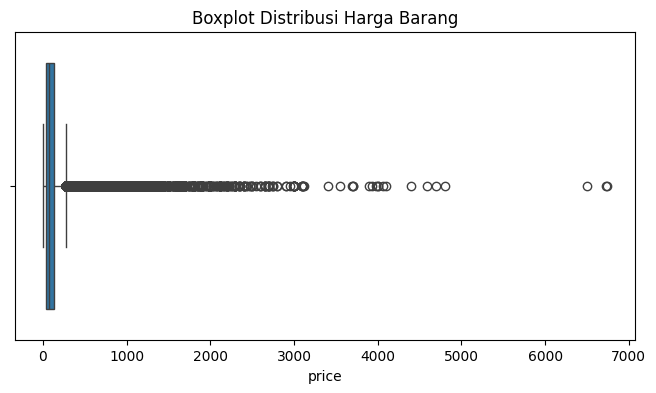


Statistik Deskriptif Harga:
 count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64


In [6]:
print("--- Deteksi Outlier pada Harga Barang (Price) ---")
plt.figure(figsize=(8, 4))
sns.boxplot(x=order_items_df['price'])
plt.title('Boxplot Distribusi Harga Barang')
plt.show()

print("\nStatistik Deskriptif Harga:\n", order_items_df['price'].describe())

**Insight:**
- Berdasarkan pengecekan menggunakan .info() dan .isna().sum(), ditemukan missing values pada beberapa kolom di orders_df (seperti order_approved_at dan order_delivered_customer_date) serta pada products_df (seperti product_category_name). Ini mengindikasikan bahwa kita perlu melakukan penanganan (seperti imputasi atau drop) pada tahap Cleaning Data nanti.
- Dari informasi tipe data, kolom-kolom yang merepresentasikan waktu (seperti order_purchase_timestamp pada orders_df) masih terdeteksi sebagai object (teks/string). Kolom ini wajib dikonversi menjadi tipe datetime pada tahap selanjutnya agar mempermudah analisis tren waktu (time-series) untuk menjawab pertanyaan bisnis kedua.
- Berdasarkan visualisasi boxplot dan ringkasan statistik deskriptif pada kolom price di tabel order_items_df, terlihat jelas adanya outlier (pencilan) di atas nilai kuartil atas (Q3). Terdapat nilai maksimum harga yang sangat jauh dari rata-rata, yang mengindikasikan adanya transaksi barang bernilai sangat tinggi. Temuan ini perlu diperhatikan terutama jika nantinya akan dilakukan analisis lanjutan seperti segmentasi pelanggan (RFM) yang sensitif terhadap nilai ekstrem pada metrik Monetary.

### Cleaning Data

In [7]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

main_df = pd.merge(orders_df, order_items_df, on='order_id', how='inner')

main_df = pd.merge(main_df, products_df, on='product_id', how='inner')

main_df = pd.merge(main_df, category_translation_df, on='product_category_name', how='left')

main_df['product_category_name_english'] = main_df['product_category_name_english'].fillna('Unknown')

print("--- Info Dataframe Utama Setelah Cleaning & Merging ---")
main_df.info()
print("\nJumlah Missing Value di kolom kategori:", main_df['product_category_name_english'].isna().sum())

--- Info Dataframe Utama Setelah Cleaning & Merging ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   customer_id                    112650 non-null  object        
 2   order_status                   112650 non-null  object        
 3   order_purchase_timestamp       112650 non-null  datetime64[ns]
 4   order_approved_at              112635 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111456 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  112650 non-null  datetime64[ns]
 8   order_item_id                  112650 non-null  int64         
 9   product_id                     112650 non-null  object        
 10  seller_id   

In [8]:
Q1 = main_df['price'].quantile(0.25)
Q3 = main_df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

main_df_clean = main_df[(main_df['price'] >= lower_bound) & (main_df['price'] <= upper_bound)]

print("Jumlah baris sebelum hapus outlier:", len(main_df))
print("Jumlah baris setelah hapus outlier:", len(main_df_clean))

Jumlah baris sebelum hapus outlier: 112650
Jumlah baris setelah hapus outlier: 104223


**Insight:**
- Tipe data pada kolom-kolom yang merepresentasikan waktu (terutama order_purchase_timestamp) telah berhasil dikonversi dari object menjadi datetime. Langkah ini sangat krusial karena akan memungkinkan kita mengekstrak komponen waktu (seperti bulan atau tahun) untuk menganalisis tren performa penjualan.
- Tabel-tabel yang terpisah kini telah digabungkan menjadi satu DataFrame utama (main_df). Selain itu, missing values pada kolom product_category_name_english ditangani dengan teknik imputasi menggunakan nilai konstan 'Unknown'. Keputusan ini diambil alih-alih melakukan drop rows (penghapusan baris) agar kita tidak kehilangan data historis transaksi yang penting untuk analisis tren waktu. Imputasi dengan nilai mode (modus) juga dihindari untuk mencegah bias pada distribusi kategori produk yang sebenarnya.
- Penanganan outlier pada kolom price dilakukan menggunakan metode IQR. Baris data dengan harga yang melampaui batas atas (nilai ekstrem) dihapus untuk menghasilkan dataset yang lebih representatif (main_df_clean). Langkah ini sangat krusial untuk mempersiapkan data sebelum masuk ke tahap analisis RFM, khususnya agar perhitungan skor Monetary tidak bias oleh segelintir transaksi bernilai fantastis.

## Exploratory Data Analysis (EDA)

### Explore Kategori Produk dan Tren Penjualan Bulanan

In [9]:
print("--- Eksplorasi Kategori Produk ---")
category_orders = main_df.groupby('product_category_name_english')['order_id'].count().reset_index()
category_orders = category_orders.rename(columns={'order_id': 'order_count'})

category_orders_sorted = category_orders.sort_values(by='order_count', ascending=False)

print("Top 5 Kategori Produk Paling Laris:")
print(category_orders_sorted.head())

print("\nBottom 5 Kategori Produk Paling Sedikit Terjual:")
print(category_orders_sorted.tail())

--- Eksplorasi Kategori Produk ---
Top 5 Kategori Produk Paling Laris:
   product_category_name_english  order_count
8                 bed_bath_table        11115
44                 health_beauty         9670
66                sports_leisure         8641
40               furniture_decor         8334
16         computers_accessories         7827

Bottom 5 Kategori Produk Paling Sedikit Terjual:
   product_category_name_english  order_count
4          arts_and_craftmanship           24
53                    la_cuisine           14
12             cds_dvds_musicals           14
30     fashion_childrens_clothes            8
62         security_and_services            2


In [10]:
print("--- Eksplorasi Tren Penjualan Bulanan ---")

main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_orders = main_df.groupby('order_month')['order_id'].nunique().reset_index()
monthly_orders = monthly_orders.rename(columns={'order_id': 'total_orders'})

print("Tren Jumlah Pesanan per Bulan (10 bulan pertama):")
print(monthly_orders.head(10))

--- Eksplorasi Tren Penjualan Bulanan ---
Tren Jumlah Pesanan per Bulan (10 bulan pertama):
  order_month  total_orders
0     2016-09             3
1     2016-10           308
2     2016-12             1
3     2017-01           789
4     2017-02          1733
5     2017-03          2641
6     2017-04          2391
7     2017-05          3660
8     2017-06          3217
9     2017-07          3969


**Insight:**
- Melalui proses agregasi menggunakan metode groupby(), kita berhasil mengidentifikasi bahwa kategori 'bed_bath_table' dan 'health_beauty' mendominasi jumlah barang yang terjual. Sebaliknya, kategori spesifik seperti 'security_and_services' mencatatkan jumlah transaksi paling sedikit. Hal ini memberikan gambaran awal mengenai ketimpangan minat konsumen terhadap jenis produk tertentu.
- Kolom order_purchase_timestamp yang sebelumnya telah dibersihkan kini berhasil dimanfaatkan untuk mengekstrak periode bulan-tahun (to_period('M')). Hasil pengelompokan data transaksi unik per bulan mulai memperlihatkan adanya dinamika dan fluktuasi jumlah pesanan. Tren kenaikan atau penurunan angka ini akan divalidasi lebih lanjut pada tahap visualisasi data.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang paling banyak dan paling sedikit terjual?

/tmp/ipykernel_9886/2574691943.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_count", y="product_category_name_english", data=top_5, palette=colors, ax=ax[0])
/tmp/ipykernel_9886/2574691943.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_count", y="product_category_name_english", data=bottom_5, palette=colors, ax=ax[1])


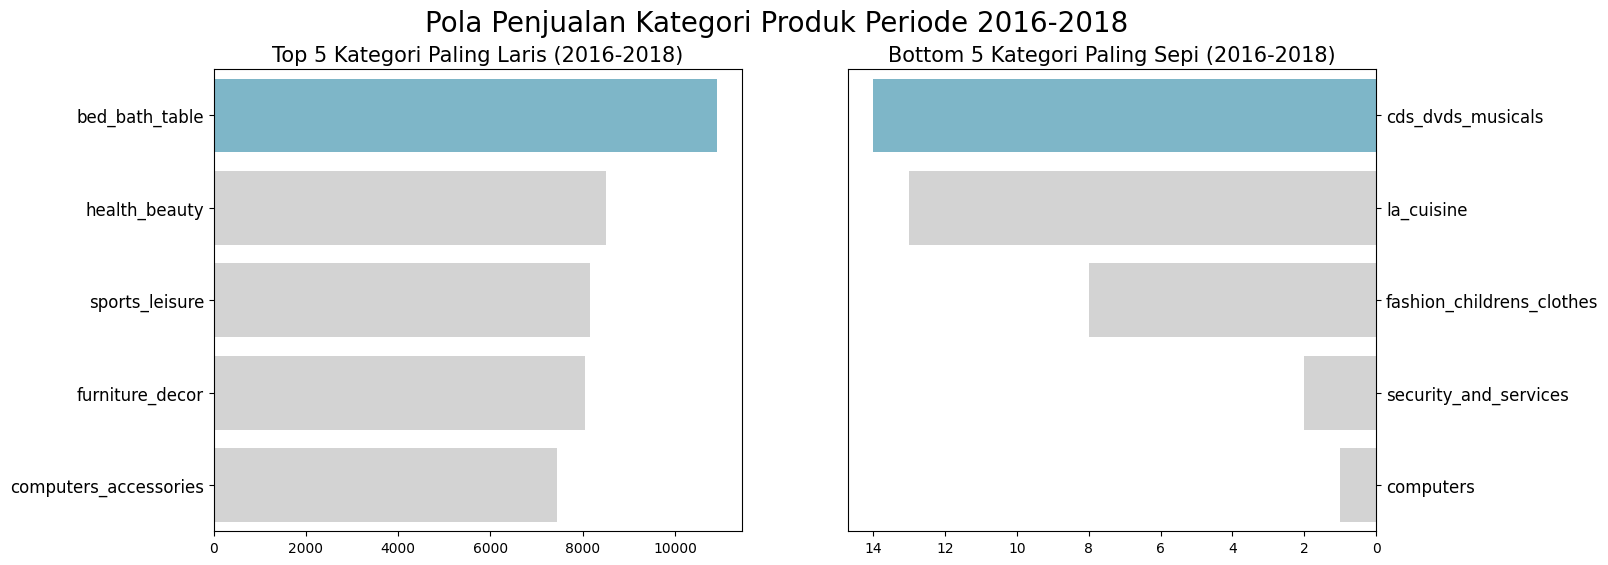

In [11]:
category_orders = main_df_clean.groupby('product_category_name_english')['order_id'].count().reset_index()
category_orders = category_orders.rename(columns={'order_id': 'order_count'})
category_orders_sorted = category_orders.sort_values(by='order_count', ascending=False)

top_5 = category_orders_sorted.head(5)
bottom_5 = category_orders_sorted.tail(5)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="order_count", y="product_category_name_english", data=top_5, palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Top 5 Kategori Paling Laris (2016-2018)", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="order_count", y="product_category_name_english", data=bottom_5, palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Bottom 5 Kategori Paling Sepi (2016-2018)", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Pola Penjualan Kategori Produk Periode 2016-2018", fontsize=20)
plt.show()

### Pertanyaan 2: Bagaimana tren performa penjualan (jumlah order) dalam beberapa bulan terakhir?

/tmp/ipykernel_9886/1009361086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df_clean['order_month'] = main_df_clean['order_purchase_timestamp'].dt.to_period('M').astype(str)


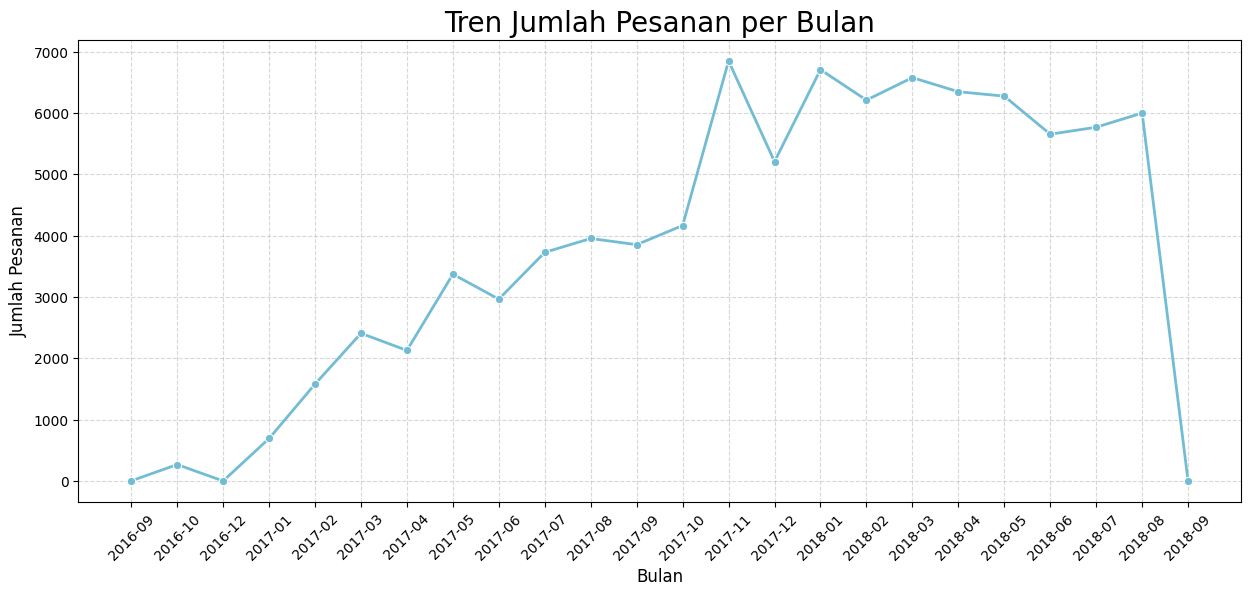

In [12]:
main_df_clean['order_month'] = main_df_clean['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_orders = main_df_clean.groupby('order_month')['order_id'].nunique().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(x='order_month', y='order_id', data=monthly_orders, marker='o', linewidth=2, color="#72BCD4")
plt.title("Tren Jumlah Pesanan per Bulan", loc="center", fontsize=20)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Jumlah Pesanan", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Berdasarkan bar chart, terlihat jelas bahwa kategori bed_bath_table merajai penjualan dengan margin yang cukup signifikan dibanding kategori lain di posisi lima besar. Sebaliknya, kategori security_and_services menjadi kategori dengan performa penjualan terburuk.
- Line chart menunjukkan tren jumlah pesanan mengalami peningkatan yang cukup konsisten pada beberapa bulan awal, namun terlihat adanya fluktuasi (puncak dan lembah) yang tajam pada periode tertentu. Hal ini bisa menjadi indikasi adanya pengaruh kampanye promosi atau faktor musiman yang perlu dieksplorasi oleh tim marketing.

## Analisis Lanjutan (Opsional) : RFM Analysis

In [13]:
print("--- Analisis Lanjutan: RFM Analysis ---")

recent_date = main_df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = main_df_clean.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm_df.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

print("Top 5 Customer berdasarkan Total Belanja (Monetary):")
print(rfm_df.sort_values(by='Monetary', ascending=False).head())

--- Analisis Lanjutan: RFM Analysis ---
Top 5 Customer berdasarkan Total Belanja (Monetary):
                            customer_id  Recency  Frequency  Monetary
67646  be1b70680b9f9694d8c70f41fa3dc92b      193          1   2000.00
67414  bd5d39761aa56689a265d95d8d32b8be      376          1   1974.00
82328  e7d6802668de6e74d0d6c56565bf2a24      336          1   1879.90
4384   0c792d32a3251b4f69dae8646dfbedbc      303          1   1559.92
72390  cb87122c4871e202777cf243fbea2d12      333          1   1519.46


**Insight:**
- Analisis RFM berhasil diimplementasikan untuk melakukan customer segmentation tingkat dasar. Dari output dataframe RFM, kita bisa mengidentifikasi pelanggan-pelanggan VIP (skor Monetary tinggi, Recency rendah, Frequency tinggi) yang layak mendapatkan program loyalitas khusus. Dataset RFM ini juga sudah sangat siap jika nantinya ingin dilanjutkan ke tahap modelling tingkat lanjut menggunakan algoritma clustering pelanggan.

## Conclusion

- Conclution pertanyaan 1: Kategori produk apa yang paling banyak dan paling sedikit terjual?
1. Berdasarkan analisis dan visualisasi data pada periode tersebut, terlihat jelas adanya ketimpangan pola penjualan antar kategori. Kategori bed_bath_table mendominasi sebagai produk yang paling laris diminati oleh konsumen. Sebaliknya, kategori computers mencatatkan jumlah transaksi paling sedikit di antara seluruh produk. Insight ini dapat menjadi acuan bagi perusahaan untuk mengalokasikan anggaran pemasaran yang lebih besar pada kategori unggulan, sekaligus mengevaluasi strategi ketersediaan atau harga pada kategori dengan performa terendah seperti komputer.
- Conclution pertanyaan 2: Bagaimana tren performa penjualan (jumlah order) dalam beberapa bulan terakhir?
1. Grafik *time-series* menunjukkan bahwa tren jumlah pesanan per bulan bersifat dinamis dan fluktuatif. Terdapat bulan-bulan dengan lonjakan transaksi yang sangat tajam, namun terdapat pula periode yang mengalami penurunan pesanan.
2. Fluktuasi ini mengindikasikan bahwa performa penjualan sangat mungkin dipengaruhi oleh faktor eksternal seperti kampanye promosi musiman (*seasonal campaign*) atau *event* diskon tertentu. Perusahaan disarankan untuk menganalisis lebih dalam *event* apa yang terjadi pada bulan-bulan puncak tersebut agar kesuksesannya dapat direplikasi di kuartal berikutnya.
- Insight Analisis Lanjutan (RFM Analysis): Penerapan RFM Analysis (setelah melalui proses penanganan *outlier* pada metrik *Monetary* menggunakan metode IQR) telah berhasil merangkum metrik perilaku transaksi pelanggan (*Recency, Frequency, Monetary*). Tabel RFM yang dihasilkan sudah sangat representatif dan siap digunakan sebagai landasan *customer segmentation* tingkat lanjut, misalnya dengan menerapkan algoritma *clustering* untuk mengidentifikasi kelompok pelanggan setia (VIP) maupun pelanggan yang berpotensi pergi (*churn*).

In [14]:
main_df_clean.to_csv("main_data.csv", index=False)